# Phase 9 · Validation, décision et explicabilité : carnet de travail

Relit les résultats de la phase 9 ; le jeu de test n'est jamais relu — seulement les scores enregistrés par la
lecture unique de restitution (R6). Règles R1 à R12 validées avant tout calcul (choix § 7 septies).

In [1]:
# --- Environment: the project package and the recorded results --------------------------------
import json
import sys
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import pandas as pd

from churn_saas.notebook import afficher_tableau


def resultat(nom):
    return json.loads((RACINE / "resultats" / f"{nom}.json").read_text(encoding="utf-8"))

## 1. Règle de décision et stabilité de la liste (sans le test)

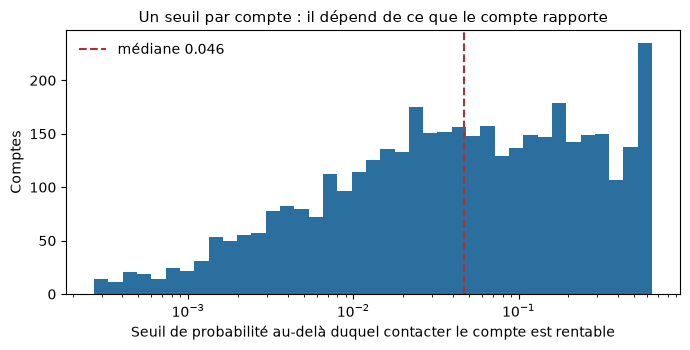

efficacité,coût d'un contact (€),comptes rentables,part rentable,comptes traités (capacité),valeur nette des comptes traités (€)
0.15,94.5,2740,0.6850,112,5229651.0
0.15,135.0,2494,0.6235,112,5225115.0
0.15,175.5,2333,0.5833,112,5220579.0
0.25,94.5,3025,0.7562,112,8723141.0
0.25,135.0,2833,0.7083,112,8718605.0
0.25,175.5,2662,0.6655,112,8714069.0
0.40,94.5,3255,0.8137,112,13963375.0
0.40,135.0,3084,0.7710,112,13958839.0
0.40,175.5,2942,0.7355,112,13954303.0


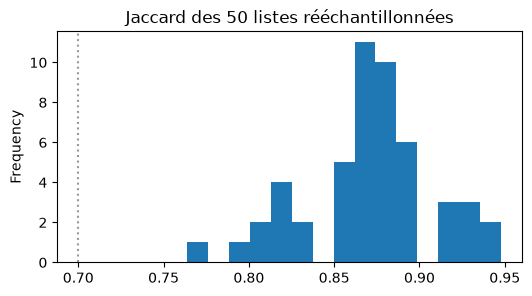

In [2]:
from churn_saas.features import tracer_seuils

regle = resultat("regle_decision")
tracer_seuils(regle["seuils_par_compte"])
plt.show()
afficher_tableau(pd.DataFrame(regle["hypotheses"]), titre="Comptes rentables selon les hypothèses")
indices = pd.Series(regle["stabilite"]["indices"])
ax = indices.plot(kind="hist", bins=15, figsize=(6, 3), title="Jaccard des 50 listes rééchantillonnées")
ax.axvline(0.70, color="#999999", linestyle=":")
plt.show()

## 2. Les scores de la lecture de restitution

In [3]:
scores = pd.read_csv(RACINE / "resultats" / "scores_test.csv", dtype={"client_id": str})
afficher_tableau(scores[scores["traite_metier"]].sort_values("rang_valeur").head(28),
                 titre="Les 28 comptes du point métier")
validation = resultat("validation_phase9")
afficher_tableau(pd.DataFrame(validation["matrices"]).T.reset_index(names="point"), titre="Matrices de confusion")

client_id,churn,proba,valeur_vie_client_eur,mrr_eur,secteur,pays,taille_entreprise,valeur_nette_eur,seuil_compte,rang_valeur,traite_metier,signale_protocole
CLI-004433,1,0.830775,1034832,36056.85,Commerce,Espagne,GE,214793.26,0.000522,1,True,True
CLI-000678,1,0.466387,790718,41925.64,Éducation,France,GE,92060.12,0.000682,2,True,False
CLI-000778,0,0.616117,589177,44906.77,Commerce,France,GE,90615.51,0.000916,3,True,False
CLI-001526,1,0.702602,489340,27125.25,Tech,France,GE,85817.83,0.001102,4,True,False
CLI-002668,0,0.522117,610590,21274.91,Tech,Espagne,GE,79564.80,0.000884,5,True,False
CLI-002154,0,0.385634,800202,39034.24,Santé,France,GE,77011.22,0.000674,6,True,False
CLI-002305,0,0.370705,773610,55495.68,Finance,France,GE,71560.19,0.000698,7,True,False
CLI-003342,1,0.355719,791566,50806.56,Tech,Belgique,GE,70258.72,0.000682,8,True,False
CLI-003136,1,0.883667,295201,9230.80,Tech,Allemagne,ETI,65079.83,0.001826,9,True,True
CLI-003591,0,0.266959,968282,69460.69,Tech,France,GE,64487.83,0.000557,10,True,False


point,vrais positifs,faux positifs,faux négatifs,vrais négatifs,précision,rappel,comptes signalés
"métier (28 comptes, valeur nette)",18.0,10.0,262.0,710.0,0.6429,0.0643,28.0
protocole (10 % les plus risqués),88.0,12.0,192.0,708.0,0.8800,0.3143,100.0


## 3. Revenu et équité

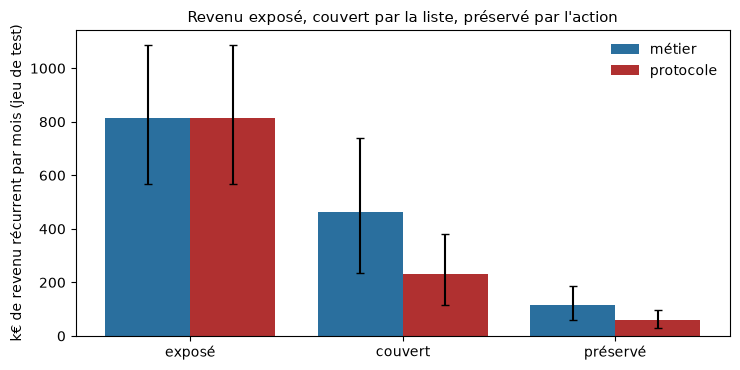

segment,modalité,comptes,départs,taux de départ,signalés,rappel,précision,concluant,critère respecté
secteur,Commerce,162,50,0.3086,13,0.2000,0.7692,True,True
secteur,Finance,170,43,0.2529,11,0.2326,0.9091,True,True
secteur,Industrie,150,42,0.2800,18,0.3810,0.8889,True,True
secteur,Public,59,18,0.3051,5,0.2778,1.0000,True,True
secteur,Santé,123,29,0.2358,11,0.3448,0.9091,True,True
secteur,Tech,168,51,0.3036,23,0.4510,1.0000,True,True
secteur,non renseigné,54,15,0.2778,9,0.4000,0.6667,True,True
secteur,Éducation,114,32,0.2807,10,0.2500,0.8000,True,True
pays,Allemagne,93,21,0.2258,7,0.2381,0.7143,True,True
pays,Belgique,95,24,0.2526,11,0.3333,0.7273,True,True


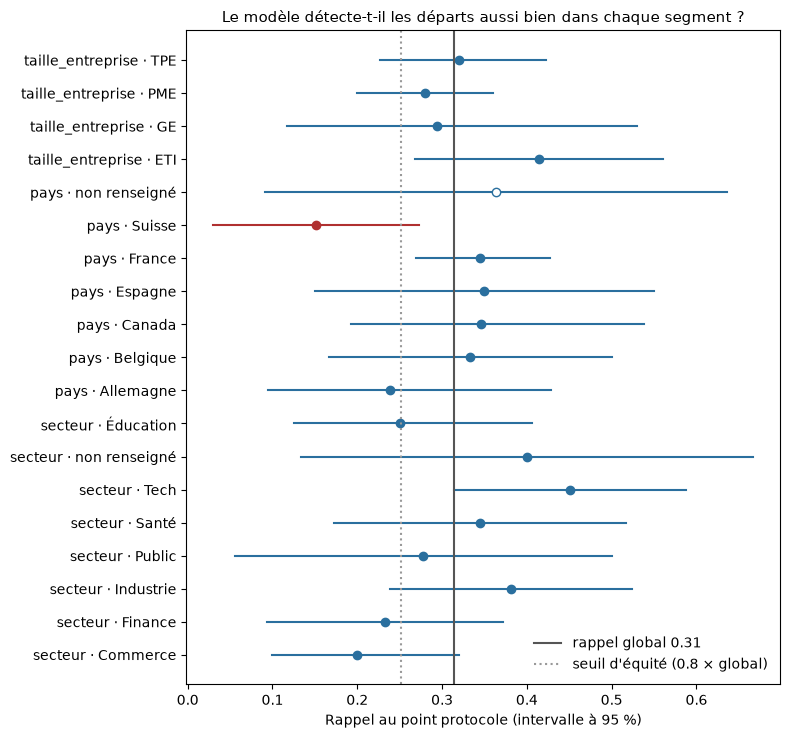

In [4]:
from churn_saas.features import tracer_equite, tracer_niveaux_mrr

tracer_niveaux_mrr(validation["mrr"])
plt.show()
equite = pd.DataFrame(validation["equite"])
afficher_tableau(equite.drop(columns=["intervalle du rappel"]), titre="Équité par segment (point protocole)")
tracer_equite(validation["equite"], validation["matrices"]["protocole (10 % les plus risqués)"]["rappel"], 0.8)
plt.show()

## 4. Importance et explications locales

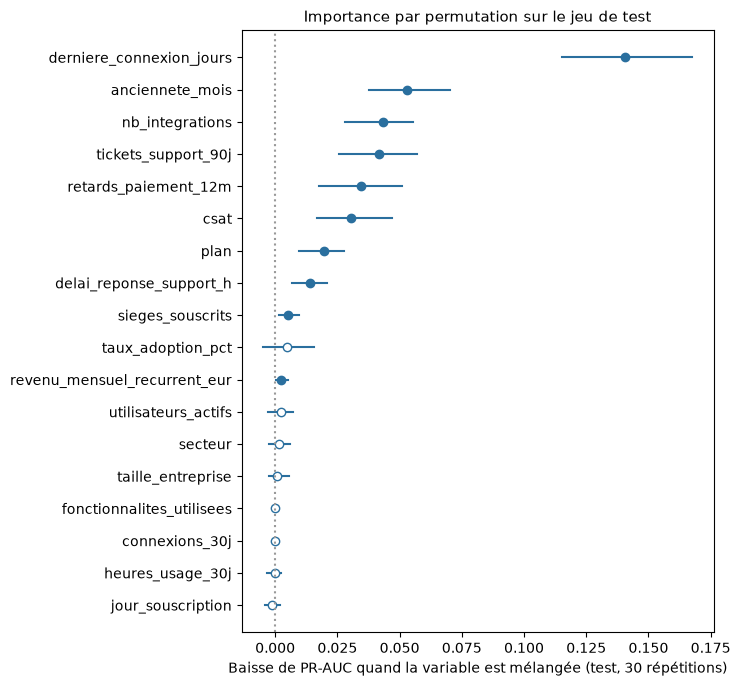

variable,valeur,contribution (cotes)
derniere_connexion_jours,45.0,1.9740
plan,Enterprise,-0.7681
nb_integrations,0.0,0.6697
taux_adoption_pct,0.0,0.6253
tickets_support_90j,0.0,-0.5859
anciennete_mois,6.0,0.4513


variable,valeur,contribution (cotes)
csat,2.0,0.6823
nb_integrations,0.0,0.6697
tickets_support_90j,5.0,0.5753
derniere_connexion_jours,1.0,-0.3508
retards_paiement_12m,nan,-0.2908
anciennete_mois,8.0,0.2633


variable,valeur,contribution (cotes)
plan,Enterprise,-0.7681
anciennete_mois,3.0,0.7333
csat,2.0,0.6823
nb_integrations,0.0,0.6697
utilisateurs_actifs,219.0,-0.6110
revenu_mensuel_recurrent_eur,44906.77,0.4968


In [5]:
from churn_saas.features import tracer_importance_test

restitution = resultat("restitution_test")
tracer_importance_test(restitution["importance_permutation"])
plt.show()
for role, e in restitution["explications_locales"].items():
    afficher_tableau(pd.DataFrame({"valeur": e["valeurs"], "contribution (cotes)": e["contributions_cotes"]})
                     .reset_index(names="variable"),
                     titre=f"{role} — probabilité {e['probabilite']:.2f}, départ réel {e['depart_reel']}")

## Journal de bord
- R3 : la capacité, pas la rentabilité, limite l'action ; R4 : la liste résiste à l'incertitude du modèle.
- R6 : une lecture de restitution unique ; tout le reste vient des scores enregistrés.
- R9 : un écart d'équité (Suisse) documenté et mis sous surveillance (R12).